## We use algorithm for classification task and found prediction, but we want to evaluate the algorithm if there wrong prediction, But first we have to calculate the metrics using,
`accuracy`
`precision and recall`
`F1 score`

## Confusion Matrix
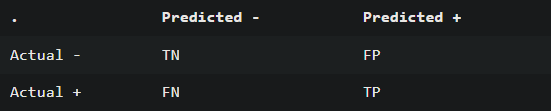

### True Positive (TP): The algorithm predicted spam and it was spam
### True Negative (TN): The algorithm predicted not spam and it was not spam
### False Positive (FP): The algorithm predicted spam and it was not spam
### False Negative (FN): The algorithm predicted not spam and it was spam

In [ ]:
from sklearn.metrics import confusion_matrix
actual = [1, 0, 0, 1, 1, 1, 0, 1, 1, 1]
predicted = [0, 1, 1, 1, 1, 0, 1, 0, 1, 0]

true_positives, true_negatives, false_positives,false_negatives = 0,0,0,0
for i in range(len(actual)):
  if actual[i]==1 and predicted[i]==1: # 1 as positive , 0 negetive
    true_positives+=1 
  elif actual[i]==0 and predicted[i]==0:
    true_negatives+=1
  elif actual[i]==0 and predicted[i]==1:
    false_positives+=1
  else:
    false_negatives+=1
    
print("true_positives: ",true_positives," true_negatives: ",true_negatives," false_positives: ", false_positives, "false_negatives: ",false_negatives)
conf_matrix = confusion_matrix(actual,predicted)
print(conf_matrix)

## Display the Confusion Matrix

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['actual','predicted'])
disp.plot()

## More Way to Display CM

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# y_true represents your true labels
# y_pred represents your predicted labels
y_true = [2, 0, 2, 2, 0, 1]
y_pred = [0, 0, 2, 2, 0, 2]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()


## Accuracy
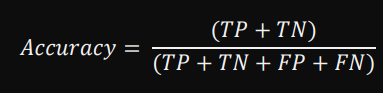


In [ ]:
from sklearn.metrics import accuracy_score

scr = true_positives+true_negatives/ len(actual)

score = accuracy_score(actual,predicted)
scr,score

## Prcision - ` how precise your model`
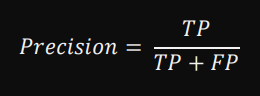
### A precision of 1 means that every item the model identified as positive was indeed positive, and there were no false positives.
### if dog classifier predict 4 dogs (True Positive) and 3 not dogs (False Positive) then precision 4/(4+3) = 0.57 got right ! 

In [ ]:
from sklearn.metrics import precision_score

pscr = true_positives/(true_positives+false_positives)

pscore = precision_score(actual,predicted)
pscr,pscore

## Recall - ` if got all the dog then perfect recall`
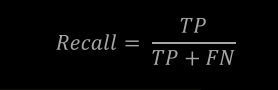
### A recall of 1 means that the model identified all positive instances correctly and there were no false negatives
### If dog test data has 6 dog and classifier predict 4 dog True positive then recall is 4/6= 0.67

In [ ]:
from sklearn.metrics import recall_score

rscr = true_positives/(true_positives+false_negatives)

rscore = recall_score(actual,predicted)
rscr,rscore

### for not a dog precision is (1-p)= (1-0.57)= 0.33, same for recall 

## F1 score - ( 0-1 with 1 best for precsion or recall or both ) 
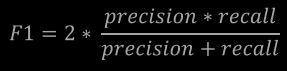

In [ ]:
from sklearn.metrics import f1_score

f1scr = 2 *(pscore*rscore)/(pscore+rscore)

f1score = f1_score(actual,predicted)
f1scr,f1score

## Another way to see all 

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(actual,predicted))

# log Loss (Cross Entropy) less is good
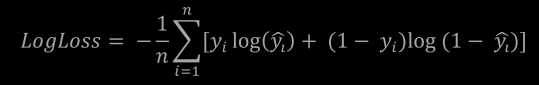

In [ ]:
from sklearn.metrics import log_loss

loss = log_loss(actual,predicted)
loss

## ROC(receiver operating characteristic curve) AUC(Area Under Curve)(0.9 to 1.0) is best 
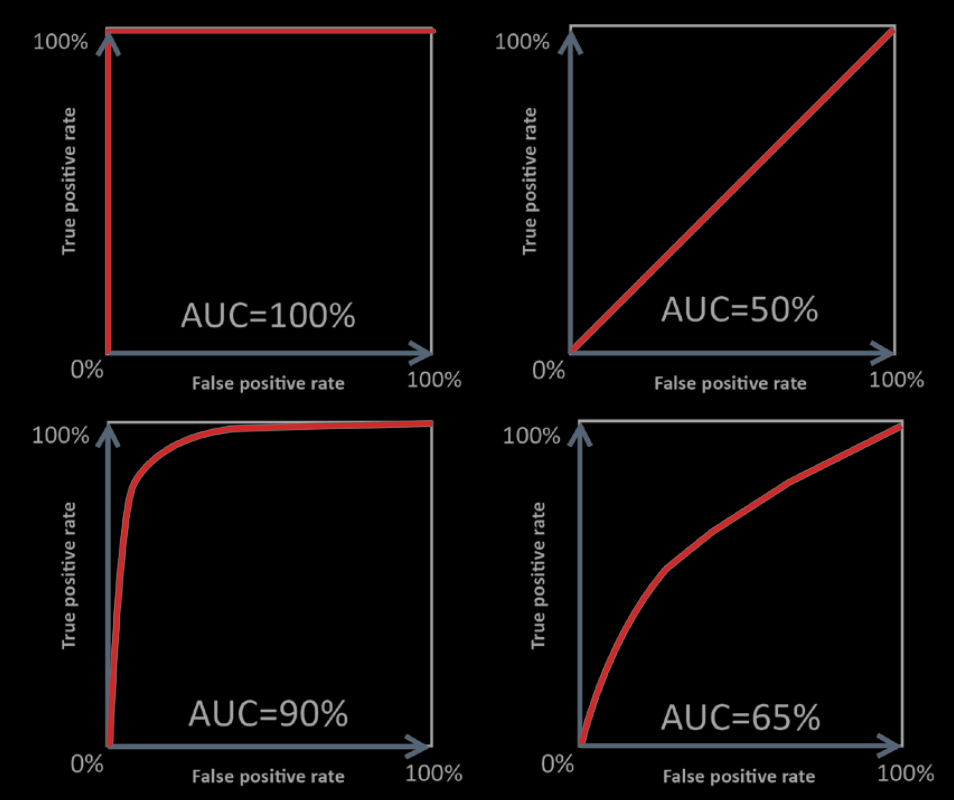

In [ ]:
from sklearn import metrics
import matplotlib.pyplot as plt

def ROC_AUC(y_test,y_pred):

    # Compute ROC curve and AUC
    fpr, tpr, _ = metrics.roc_curve(y_test,y_pred)
    roc_auc = metrics.roc_auc_score(y_test,y_pred)

    # Plot
    plt.figure()
    lw = 2
    plt.plot(fpr, tpr, color='darkorange',
             lw=lw, label='AUC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic example')
    plt.legend(loc="lower right")
    plt.show()

In [ ]:
y_test_worst=[1,0,0,1]
y_pred_worst=[1,0,1,0]


ROC_AUC(y_test_worst,y_pred_worst)